# Week 11 P1 — Region-crop 캡션: 구조 따라가기

> 구현: `src/region_caption.py` · 캐시: `data/week11_captions_crop.json` · crop 이미지: `data/region_crops/`

**왜 이걸 만들었나.** Week 9(인덱스측 페이지 캡션)와 Week 11 agent(질의측 페이지 vision, F2)가 같은 상한에 부딪혔다:
**페이지 전체**를 읽으면 gpt-4o도 작은 아이콘 모양·부품 위치·방향을 못 읽는다.
돌파구는 한 단계 내려가는 것 — **그림 영역만 잘라서 아이콘이 프레임을 채우게** 만들기.

파이프라인은 3단계이고, 이 노트북은 한 단계씩 눈으로 확인한다 (전부 오프라인 — 캡션은 캐시에서 읽음):

```
① detect_regions   vector drawing → 점유 그리드 → 연결 성분 → 영역 bbox
② render_crops     bbox를 PDF에서 300dpi로 직접 렌더 (vector라 얼마든 선명)
③ caption_region   gpt-4o가 crop + 주변 인쇄 텍스트를 읽고 구조화 JSON 반환
```

In [1]:
import json
import os
from pathlib import Path

if Path.cwd().name == "w11":
    os.chdir("..")
print(Path.cwd())

/Users/joyoungha/Desktop/project/rag-agent-portfolio


## ① 영역 검출 — vector drawing의 점유 그리드

매뉴얼 도면은 raster 이미지가 아니라 **vector line-art**다 (LIM-002 — XObject 추출이 안 되는 이유이자,
여기서 `page.get_drawings()`로 접근 가능한 이유). 한 페이지에 path가 ~9,000개라 쌍별 클러스터링은 불가능하고,
대신 **4pt 격자에 drawing rect를 찍고 → 팽창(dilate)으로 획 사이 틈을 메우고 → 연결 성분의 bbox**를 취한다.
페이지 면적 5% 미만은 버림 (헤더 배너 ~4%가 걸러지는 걸 실측으로 확인).

(112, 104, 400, 296) → 페이지 상단 중앙
(248, 296, 428, 508) → 페이지 중단 우측


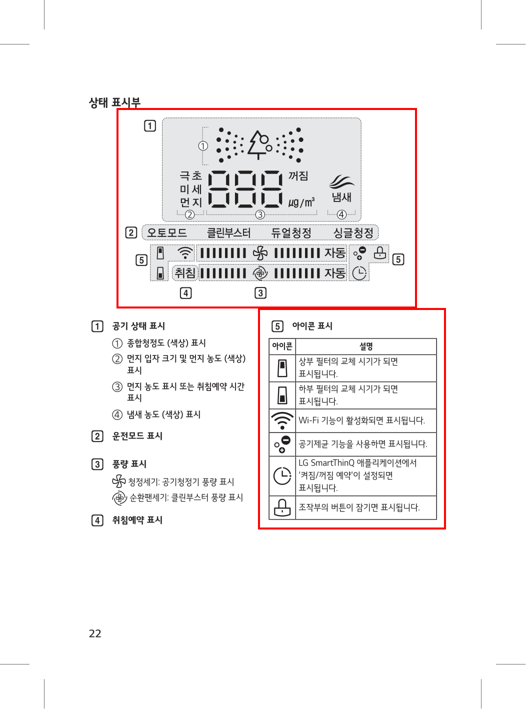

In [2]:
import pymupdf
from PIL import Image, ImageDraw
from src.region_caption import detect_regions, position_label, _pdf_for

# IR-A3의 무대: airpurifier_complex p22 (상태 표시부 + 아이콘 표)
doc = pymupdf.open(str(_pdf_for("airpurifier_complex")))
page = doc[22 - 1]
boxes = detect_regions(page)
for b in boxes:
    print(tuple(round(v) for v in b), "→", position_label(b, page.rect))

# 검출 결과를 150dpi 페이지 위에 그려서 확인
img = Image.open("data/sample_images_150/airpurifier_complex/p022.png").convert("RGB")
s = 150 / 72  # PDF pt → 150dpi px
draw = ImageDraw.Draw(img)
for b in boxes:
    draw.rectangle([v * s for v in b], outline=(255, 0, 0), width=4)
img.resize((img.width // 2, img.height // 2))

## ② 300dpi crop — "아이콘이 프레임을 채운다"

150dpi **페이지**에서 못 읽던 아이콘이, 300dpi **crop**에서는 화면 대부분을 차지한다.
vector PDF는 `get_pixmap(clip=bbox, dpi=300)`으로 얼마든지 선명하게 렌더된다 — 추가 비용 없음.

crop 크기: (751, 884) — 같은 표가 150dpi 페이지에선 절반 이하 폭이었다


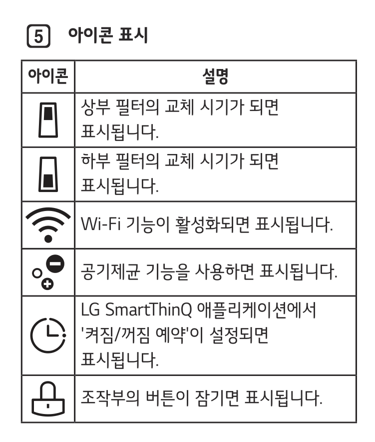

In [3]:
# 이미 렌더된 crop (python -m src.region_caption 산출물): 아이콘 표 영역
crop = Image.open("data/region_crops/airpurifier_complex/p022_r1.png")
print(f"crop 크기: {crop.size} — 같은 표가 150dpi 페이지에선 절반 이하 폭이었다")
crop.resize((crop.width // 2, crop.height // 2))

## ③ 구조화 JSON 캡션 — 무엇이 새로 잡혔나

프롬프트 원칙은 Week 9 v2를 계승(있는 것만, 라벨 원문 전사, 빗금·사선 확인 강제)하되
**영역 하나 + JSON 강제 + 주변 인쇄 텍스트 주입**으로 좁혔다.
페이지 내 위치(상/중/하 × 좌/중앙/우)는 VLM에게 묻지 않고 **bbox에서 기하로 계산**한다 — 환각 여지 제거.

In [4]:
rows = json.loads(Path("data/week11_captions_crop.json").read_text())
print(f"캐시: {len(rows)}개 영역 (IR8 관련 5페이지)\n")

def show(category, page, region_idx):
    row = next(r for r in rows if (r["category"], r["page"], r["region_idx"]) == (category, page, region_idx))
    print(f"■ {row['category']}_{row['complexity']} p{row['page']} r{row['region_idx']} — {row['position']}")
    print("  summary:", row["caption"]["summary"])
    for el in row["caption"].get("elements", []):
        print(f"   · label={el.get('label')!r}")
        print(f"     shape={el.get('shape')!r}  pos={el.get('position_in_figure')}  dir={el.get('direction')}")
    print()

# Week 9에서 실패했던 바로 그 정보들:
show("airpurifier", 22, 1)      # IR-A3: 공기제균 아이콘 '모양' — 이제 shape 필드에 있음
show("vacuumcleaner", 19, 1)    # IR-V3: Wi-Fi 끊김 아이콘 — '사선'이 처음으로 잡힘
show("vacuumcleaner", 15, 2)    # IR-V2: 거치 방향 — direction 필드에 '아래로 끼움'

캐시: 12개 영역 (IR8 관련 5페이지)

■ airpurifier_complex p22 r1 — 페이지 중단 우측
  summary: 아이콘과 설명이 나열된 표
   · label='상부 필터의 교체 시기가 되면 표시됩니다.'
     shape='사각형, 내부에 세로 막대'  pos=좌측 상단  dir=None
   · label='하부 필터의 교체 시기가 되면 표시됩니다.'
     shape='사각형, 내부에 세로 막대'  pos=좌측 중단  dir=None
   · label='Wi-Fi 기능이 활성화되면 표시됩니다.'
     shape='부채꼴, 내부에 3개의 곡선'  pos=좌측 중단  dir=None
   · label='공기제균 기능을 사용하면 표시됩니다.'
     shape='원, 내부에 +와 - 기호'  pos=좌측 중단  dir=None
   · label="LG SmartThinQ 애플리케이션에서 '켜짐/꺼짐 예약'이 설정되면 표시됩니다."
     shape='원, 내부에 시계 모양'  pos=좌측 하단  dir=None
   · label='조작부의 버튼이 잠기면 표시됩니다.'
     shape='사각형, 내부에 자물쇠 모양'  pos=좌측 하단  dir=None

■ vacuumcleaner_complex p19 r1 — 페이지 하단 중앙
  summary: Wi-Fi 연결 상태를 나타내는 아이콘과 설명
   · label='연결 됨'
     shape='원형, 내부에 점과 곡선'  pos=좌상  dir=None
   · label='연결 끊김'
     shape='원형, 내부에 점과 곡선, 사선'  pos=좌중  dir=None
   · label='표시 안됨'
     shape='텍스트만'  pos=좌하  dir=None

■ vacuumcleaner_complex p15 r2 — 페이지 중단 좌측
  summary: 청소기를 충전대에 거치하는 방법
   · label=None
     shape='사각형 모양의 

## ④ 검색 청크로의 변환 — Week 12가 이어받는 지점

`region_caption_to_document`가 JSON 캡션을 Week 9 페이지 캡션과 **같은 메타데이터 계약**의
`image-derived` 청크로 만든다 → mm 스토어에 그대로 추가 가능(리트리버 변경 불필요).
`region_bbox` 메타데이터는 agent의 `image_analysis_tool(bbox=...)`(F2 에스컬레이션)과도 연결된다.

In [5]:
from src.region_caption import region_caption_to_document

doc_chunk = region_caption_to_document(
    next(r for r in rows if (r["category"], r["page"], r["region_idx"]) == ("vacuumcleaner", 19, 1))
)
print("--- page_content (리트리버가 보게 될 텍스트):")
print(doc_chunk.page_content)
print("\n--- metadata:")
for k, v in doc_chunk.metadata.items():
    print(f"  {k}: {v}")

--- page_content (리트리버가 보게 될 텍스트):
[그림 영역 — 페이지 하단 중앙] Wi-Fi 연결 상태를 나타내는 아이콘과 설명
연결 됨 · 원형, 내부에 점과 곡선 · 좌상
연결 끊김 · 원형, 내부에 점과 곡선, 사선 · 좌중
표시 안됨 · 텍스트만 · 좌하

--- metadata:
  chunk_id: vacuumcleaner_complex_p019_r1_caption
  source: p019_r1.png
  category: vacuumcleaner
  complexity: complex
  page: 19
  section: 
  modality: image-derived
  figure_ref: vacuumcleaner_complex p.19 fig:r1
  region_bbox: [24.0, 560.0, 492.0, 696.0]
  region_position: 페이지 하단 중앙


## 정리

- **잡힌 것 (Week 9 실패 6건 대비):** IR-V3의 사선(끊김 표시), IR-A3의 아이콘 모양, IR-V2의 방향 — 페이지 단위에선 불가능했던 정보가 crop 캡션의 `shape`/`direction` 필드에 들어왔다.
- **아직 부분적인 것:** IR-A1/V1(부품 위치) — p18 crop이 콜아웃 9개를 전부 전사하지 못함. 콜아웃 라벨 리스트가 crop 밖(본문)에 있는 구조적 이유 → 주변 텍스트 margin 확대 또는 콜아웃-라벨 매핑 후처리가 후보.
- **Week 12:** 이 청크들을 mm 스토어에 추가 → IR8 재평가 → 결과로 ADR-012 (크로스모달 MVP 결론) 작성.
- 같은 주에 **golden set v3** (`data/eval/golden_set_v3.csv`)도 정비: Q01(필터별 주기), Q06(1년 — p.35 표를 300dpi crop으로 확정), Q11(4시간), Q19(모델 명시 + 매뉴얼 절차). 재평가는 v3 기준으로.